In [1]:
import numpy as np
from scipy.optimize import brentq

from eigenstate_solving import BZ_proj
from model import square_lattice


def LHS_Kz(Kz, q, E, r_para, Q_para):
    """
    Solve for total momentum Kz from on-shell condition.
    F(Kz; q) = E1 + E2 - E.
    Uses np.hypot for numerical stability:
        hypot(a,b) = sqrt(a^2 + b^2).
    """
    abs_r_para = np.linalg.norm(r_para)
    abs_s_para = np.linalg.norm(BZ_proj(Q_para - r_para, square_lattice))

    k1z = 0.5 * Kz + q
    k2z = 0.5 * Kz - q

    E1 = np.hypot(abs_r_para, k1z)
    E2 = np.hypot(abs_s_para, k2z)

    return E1 + E2 - E


def q_bounds(E, r_para, Q_para):
    """
    Allowed q interval for propagating channels.
    Requires E >= m1 + m2.
    """
    abs_r_para = np.linalg.norm(r_para)
    abs_s_para = np.linalg.norm(BZ_proj(Q_para - r_para, square_lattice))
    if E < abs_r_para + abs_s_para:
        raise ValueError("No propagating two-photon channel: E < m1 + m2.")
    if (E - abs_r_para) ** 2 - abs_s_para**2 < 0 or (
        E - abs_s_para
    ) ** 2 - abs_r_para**2 < 0:
        raise ValueError("Negative value under square root in q_bounds.")
    q_min = -0.5 * np.sqrt((E - abs_r_para) ** 2 - abs_s_para**2)
    q_max = 0.5 * np.sqrt((E - abs_s_para) ** 2 - abs_r_para**2)

    return q_min, q_max


def solve_Kz(q, E, r_para, Q_para, xtol=1e-12, rtol=1e-12):
    """
    Solve F(Kz; q)=0 on the physical branch k1z,k2z >= 0.
    Returns Kz.
    """
    q_min, q_max = q_bounds(E, r_para, Q_para)

    if q < q_min - 1e-13 or q > q_max + 1e-13:
        raise ValueError(f"q={q} is outside allowed interval [{q_min}, {q_max}].")

    K_low = 2.0 * abs(q)
    K_high = E

    f_low = LHS_Kz(K_low, q, E, r_para, Q_para)
    f_high = LHS_Kz(K_high, q, E, r_para, Q_para)

    # Root can sit exactly at endpoint, especially near grazing thresholds.
    if abs(f_low) < xtol:
        return K_low
    if abs(f_high) < xtol:
        return K_high

    if f_low > 0 or f_high < 0:
        raise RuntimeError(f"Bad bracket: F(K_low)={f_low}, F(K_high)={f_high}.")

    return brentq(
        lambda K: LHS_Kz(K, q, E, r_para, Q_para),
        K_low,
        K_high,
        xtol=xtol,
        rtol=rtol,
        maxiter=100,
    )


In [2]:
from smatrix import create_self_energy_interpolator_numba
from src.model import alpha, self_energy, square_lattice

sigma_data = np.load("data/sigma_grid0f1a.npz")
kx = sigma_data["kx"]
ky = sigma_data["ky"]
sigma_grid = sigma_data["sigma_grid"]
sigma_func_period_numba = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)
collective_lamb_shift = self_energy(
    0, 0, square_lattice.a, square_lattice.d, square_lattice.omega_e, alpha
).real
sigma_func_period = create_self_energy_interpolator_numba(
    kx, ky, sigma_grid, lattice=square_lattice
)

k_para = np.array([50, 50])
E = square_lattice.omega_e

kz = np.sqrt(E**2 - np.hypot(k_para[0], k_para[1]) ** 2)
k = np.concatenate((k_para, np.array([kz])))

print(square_lattice.ge(k))
print(
    (
        -2
        * square_lattice.a**2
        * np.imag(sigma_func_period(k_para[0], k_para[1]))
        * (kz / E)
    )
    ** (1 / 2)
)


0.02658680776358274
0.026632261853533755


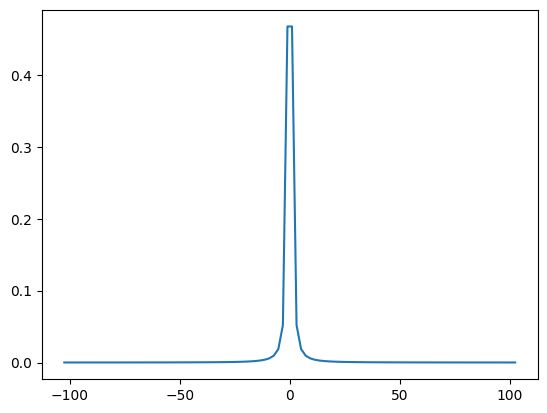

In [24]:
import matplotlib.pyplot as plt

from src.eigenstate_solving import BZ_proj
from src.smatrix.amplitudes import t_reg


def W_profile_BM(
    r_para, q, p_para, E1, E, Q_para, lattice, sigma_func_period, eps=1e-10
):
    Kz = solve_Kz(q, E, r_para, Q_para)
    rz = Kz / 2 + q
    sz = Kz / 2 - q

    Et = np.sqrt(np.linalg.norm(r_para) ** 2 + rz**2)

    J1 = 2 / ((rz / Et) + (sz / (E - Et)))
    J2 = Et / rz
    J3 = (E - Et) / sz
    s_para = BZ_proj(Q_para - r_para, lattice)
    # eigenvalue of this W state
    tt = t_reg(p_para, E1, lattice, sigma_func_period) * t_reg(
        BZ_proj(Q_para - p_para, lattice), E - E1, lattice, sigma_func_period
    )

    denom = (
        (
            Et
            - square_lattice.omega_e
            - np.conjugate(sigma_func_period(r_para[0], r_para[1]))
        )
        * (
            E
            - Et
            - square_lattice.omega_e
            - np.conjugate(sigma_func_period(s_para[0], s_para[1]))
        )
        - tt
        * (Et - square_lattice.omega_e - sigma_func_period(r_para[0], r_para[1]))
        * (E - Et - square_lattice.omega_e - sigma_func_period(s_para[0], s_para[1]))
        + 1j * eps
    )

    return J1 * J2 * J3 * 1 / denom


def W_k_sp_grid(
    r_para, p_para, E1, E, Q_para, Zc, lattice, sigma_func_period,n_points, eps=1e-10
):
    q_min, q_max = q_bounds(E, r_para, Q_para)
    q_grid = np.linspace(q_min + eps, q_max - eps, n_points)
    value_grid = np.zeros(len(q_grid), dtype=np.complex128)
    i = 0
    for q in q_grid:
        Kz = solve_Kz(q, E, r_para, Q_para)
        value_grid[i] = W_profile_BM(
            r_para, q, p_para, E1, E, Q_para, lattice, sigma_func_period
        ) * np.exp(1j * Zc * Kz)  # positive sign for outgoing wave
        i += 1
    return q_grid, value_grid


q_grid, value_grid = W_k_sp_grid(
    np.array([0, 0]),
    np.array([0, 0]),
    205 / 2,
    205,
    np.array([0, 0]),
    0,
    square_lattice,
    sigma_func_period,100
)

plt.plot(q_grid, np.abs(value_grid))

In [29]:
from scipy.integrate import quad

r_para = np.array([0, 0])
p_para = np.array([0, 0])
E1 = 205 / 2
E = 205
Q_para = np.array([0, 0])
lattice = square_lattice
sigma_func_period = sigma_func_period_numba
Zc = 0
q_min, q_max = q_bounds(E, r_para, Q_para)
z=0

re_integ = quad(
    lambda q: (
        np.real(W_profile_BM(r_para, q, p_para, E1, E, Q_para, lattice, sigma_func_period)
        * np.exp(1j * Zc * solve_Kz(q, E, r_para, Q_para)) * np.exp(1j*q*z))
    ),
    q_min,
    q_max,
)
im_integ = quad(
    lambda q: (
        np.imag(W_profile_BM(r_para, q, p_para, E1, E, Q_para, lattice, sigma_func_period)
        * np.exp(1j * Zc * solve_Kz(q, E, r_para, Q_para)) * np.exp(1j*q*z))
    ),
    q_min,
    q_max,
)

print(tuple((re_integ[0],im_integ[0])))

(0.009756099933141277, -0.0006162512667782966)


In discrete FFT, $\Delta q=2\times (q_{max}-q_{min})/n$, $L=\pi/\Delta k$, $\Delta x=2L/n$.

(0.14925101014037592+2.3497552426882518j)
(-2.373490144104415+0.15075859646054293j)


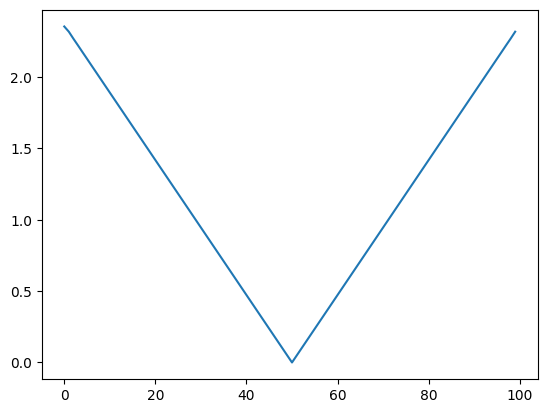

In [ ]:
from scipy.fft import ifft

n_points = 100
dq = q_grid[1] - q_grid[0]
L = np.pi / dq
dx = 2 * L / n_points
z_grid = np.linspace(-L,L,n_points,endpoint=False)

value_grid_ifft = (q_max-q_min)*ifft(value_grid)



print([value_grid_ifft[idx] * np.exp(1j*z_grid[idx]*q_min) for idx in range(n_points)][0])
  

#print(value_grid_ifft[n_points//2])
plt.plot(np.abs(value_grid_ifft))
plt.show()

